In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [2]:
df = pd.read_csv('winequality-red.csv')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [13]:
# Convert Target to Binary: 1 = Good (>= 7), 0 = Bad/Average (< 7)
df['good_quality'] = (df['quality'] >= 7).astype(int)

In [14]:
X = df.drop(columns=['quality', 'good_quality'])
y = df['good_quality']

In [15]:
# Train/Test Split (using stratify to preserve class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [16]:
#Feature Scaling (Crucial for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
# Train KNN Classifier (using distance weighting)
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', metric='euclidean')
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7, weights='distance')

In [18]:
y_pred = knn.predict(X_test_scaled)

In [20]:
print(f'Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n')
print('Classification Report:')
print(
    classification_report(
        y_test, y_pred, target_names=['Bad/Average (<7)', 'Good (>=7)']
    )
)

Model Accuracy: 91.88%

Classification Report:
                  precision    recall  f1-score   support

Bad/Average (<7)       0.94      0.97      0.95       277
      Good (>=7)       0.76      0.58      0.66        43

        accuracy                           0.92       320
       macro avg       0.85      0.78      0.81       320
    weighted avg       0.91      0.92      0.91       320



In [21]:
# Get probabilities for class 1 (Good quality)
y_probs = knn.predict_proba(X_test_scaled)[:, 1]
# Predict '1' if probability > 0.35
y_pred_custom = (y_probs > 0.35).astype(int)

In [24]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define Hyperparameter Grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
}

# Run Stratified 5-Fold Grid Search
grid_search = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1_macro',
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print(f'Best Parameters: {grid_search.best_params_}')
print(f'Best CV Macro F1: {grid_search.best_score_:.4f}')

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
Best CV Macro F1: 0.7472


In [25]:
# Evaluate the best model selected by Grid Search
best_knn = grid_search.best_estimator_
y_pred = best_knn.predict(X_test_scaled)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Bad/Average (<7)', 'Good (>=7)']))

Test Accuracy: 92.81%

Classification Report:
                  precision    recall  f1-score   support

Bad/Average (<7)       0.94      0.98      0.96       277
      Good (>=7)       0.83      0.58      0.68        43

        accuracy                           0.93       320
       macro avg       0.89      0.78      0.82       320
    weighted avg       0.92      0.93      0.92       320



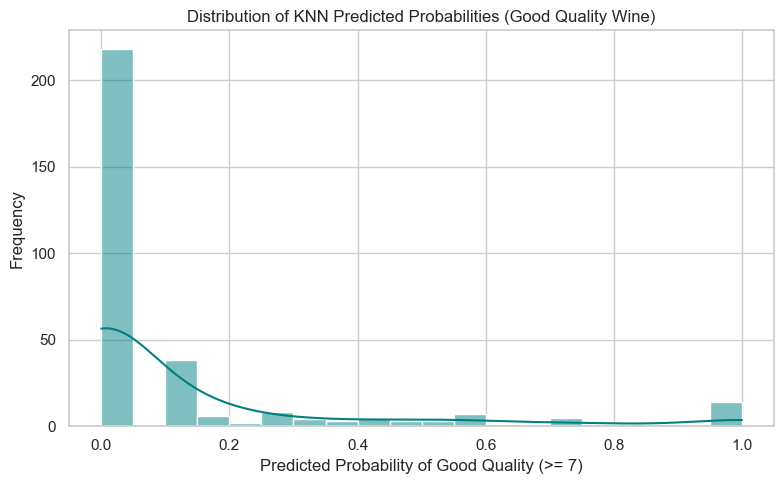

C:\Users\vaibh\AppData\Local\Temp\ipykernel_3512\2203907965.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quality_counts.index, y=quality_counts.values, palette='Blues_r')


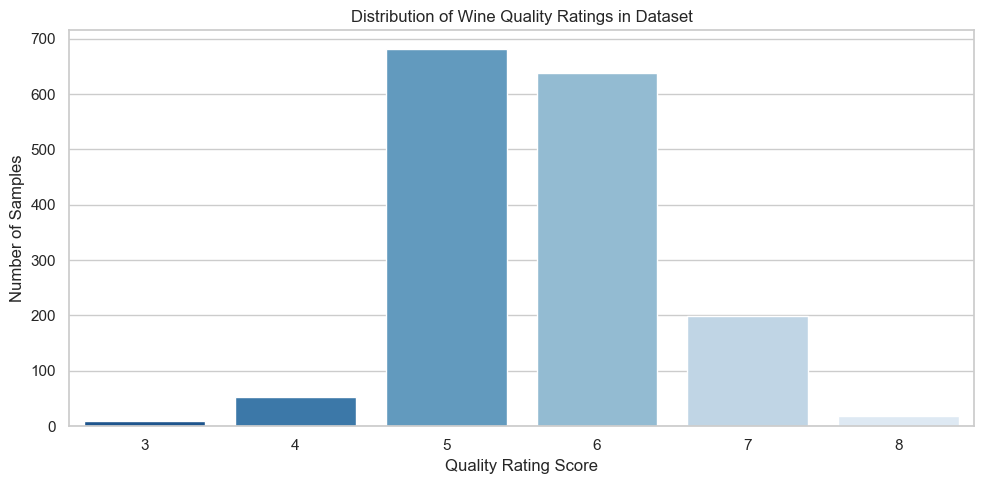

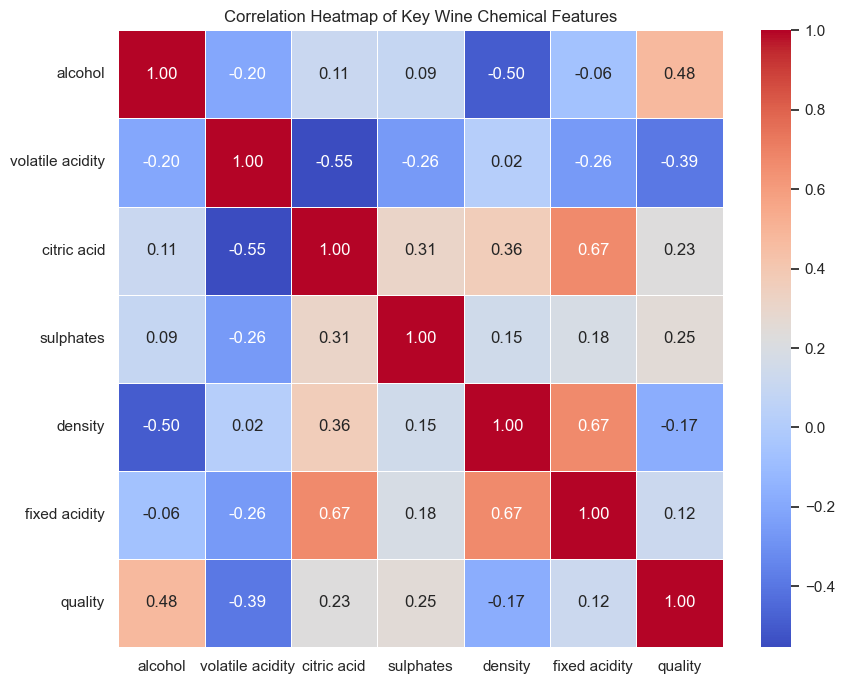

In [29]:
# Set Seaborn Theme
sns.set_theme(style='whitegrid')

# --- Plot 1: Distribution of KNN Predicted Probabilities ---
plt.figure(figsize=(8, 5))
y_probs = knn.predict_proba(X_test_scaled)[:, 1]  # Probability of Good Quality
sns.histplot(y_probs, bins=20, kde=True, color='teal')
plt.title('Distribution of KNN Predicted Probabilities (Good Quality Wine)')
plt.xlabel('Predicted Probability of Good Quality (>= 7)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# --- Plot 2: Wine Distribution by Quality Rating ---
plt.figure(figsize=(10, 5))
quality_counts = df['quality'].value_counts().sort_index()
sns.barplot(x=quality_counts.index, y=quality_counts.values, palette='Blues_r')
plt.title('Distribution of Wine Quality Ratings in Dataset')
plt.xlabel('Quality Rating Score')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

# --- Plot 3: Correlation Heatmap of Key Chemical Features ---
plt.figure(figsize=(9, 7))
key_features = [
    'alcohol',
    'volatile acidity',
    'citric acid',
    'sulphates',
    'density',
    'fixed acidity',
    'quality',
]
correlation_matrix = df[key_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.title('Correlation Heatmap of Key Wine Chemical Features')
plt.tight_layout()
plt.show()

In [34]:
import pickle

# Save the trained KNN model
with open('KNN Classifier.pkl', 'wb') as file:
    pickle.dump(knn, file)